## Import Libraries

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

## Load Dataset

In [46]:
df = pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')

print(df.head())

print(df['sentiment'].dtype)
print(df['sentiment'].unique())


                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
object
['positive' 'negative']


## Preprocessing

In [47]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print(df['sentiment'].unique())
print(df['sentiment'].value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'], test_size=0.2
)


[1 0]
sentiment
1    25000
0    25000
Name: count, dtype: int64


## Tokenization

In [48]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)

X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

## Padding

In [51]:
X_train = pad_sequences(X_train, maxlen=200)
X_test = pad_sequences(X_test, maxlen=200)

## BuilD LSTM Model

In [52]:
model = Sequential([
    Embedding(10000, 128, input_length=200),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## Train Model

In [53]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 62s 120ms/step - accuracy: 0.7246 - loss: 0.5214 - val_accuracy: 0.8461 - val_loss: 0.3667
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 60s 119ms/step - accuracy: 0.9047 - loss: 0.2446 - val_accuracy: 0.8826 - val_loss: 0.2832
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 60s 120ms/step - accuracy: 0.9334 - loss: 0.1742 - val_accuracy: 0.8805 - val_loss: 0.3162
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 61s 121ms/step - accuracy: 0.9545 - loss: 0.1273 - val_accuracy: 0.8739 - val_loss: 0.3735
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 60s 121ms/step - accuracy: 0.9503 - loss: 0.1308 - val_accuracy: 0.8676 - val_loss: 0.3556


## Evaluate Model

In [55]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.8616 - loss: 0.3774
Test Accuracy: 0.8618999719619751


## Accuracy Graph

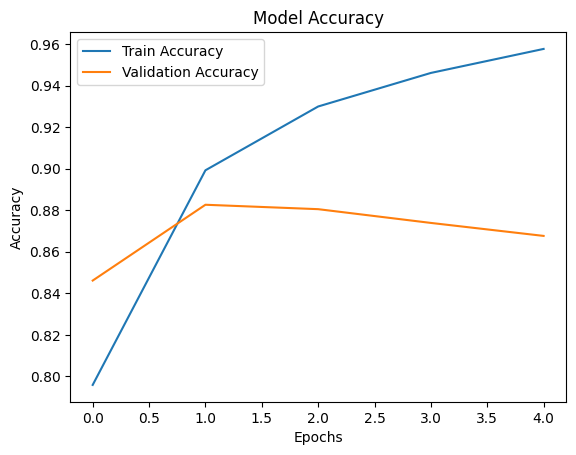

In [56]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

## Loss Graph

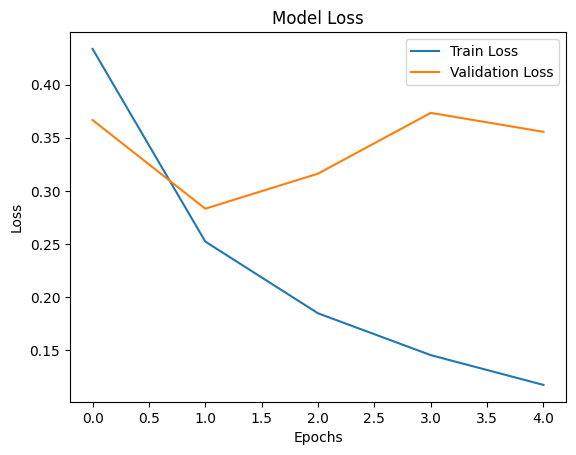

In [57]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')
plt.show()